# Robot Navigation Action Classification

Programming in Python Final-Term Group Project

## 1. Dataset and Problem Context

The goal of this project is to classify the navigation action of a mobile robot using ultrasonic sensor readings.

Each observation contains readings from 24 ultrasonic sensors positioned around the robot. The target variable represents one of four navigation actions:

- Move-Forward
- Slight-Right-Turn
- Sharp-Right-Turn
- Slight-Left-Turn

The dataset contains 5,456 observations.

Source: UCI Machine Learning Repository, Wall-Following Robot Navigation Data.

DOI: 10.24432/C57C8W

### Data Collection Context

The dataset is sequential. The SCITOS G5 robot navigated the room clockwise for four rounds, and the ultrasonic sensor readings were sampled at approximately 9 observations per second.

Because consecutive observations were collected close together in time, the sequential nature of the data should be considered later when designing the training, validation, and test split.

## 2. Import Libraries


In [95]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")




## 3. Load the Dataset

In [96]:
sensor_columns = [
    "US1", "US2", "US3", "US4", "US5", "US6",
    "US7", "US8", "US9", "US10", "US11", "US12",
    "US13", "US14", "US15", "US16", "US17", "US18",
    "US19", "US20", "US21", "US22", "US23", "US24"
]

column_names = sensor_columns + ["Class"]

print(column_names)

['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [97]:
df_raw = pd.read_csv(
    "../data/raw/sensor_readings_24.data",
    sep=",",
    header=None,
    names=column_names
)

In [98]:
# Keep the raw DataFrame unchanged and work on a copy
df = df_raw.copy()

## 4. Initial Dataset Inspection

In [99]:
df.head(10)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.000,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.000,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.000,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.000,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.000,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn
5,0.439,0.498,3.626,3.629,5.0,2.918,5.000,2.633,2.334,2.645,...,0.589,0.502,0.493,0.504,0.446,0.431,0.444,0.444,0.430,Slight-Right-Turn
6,0.440,5.000,3.627,3.628,5.0,2.919,3.028,2.346,2.330,2.638,...,0.588,0.501,0.492,0.504,0.451,0.433,0.446,0.444,0.432,Slight-Right-Turn
7,0.444,5.021,3.631,3.634,5.0,2.919,5.000,2.626,2.327,2.638,...,0.595,0.500,0.491,0.503,0.453,0.436,0.448,0.444,0.436,Slight-Right-Turn
8,0.451,5.025,3.635,3.639,5.0,2.920,3.027,2.620,2.323,2.632,...,0.595,0.499,0.491,0.502,0.457,0.440,0.453,0.454,0.442,Sharp-Right-Turn
9,0.458,5.022,3.640,3.644,5.0,2.922,5.000,2.346,2.321,2.628,...,0.590,0.496,0.490,0.498,0.462,0.444,0.458,0.461,0.449,Sharp-Right-Turn


In [100]:
df.tail(7)

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
5449,1.646,3.925,3.958,2.771,2.756,2.337,2.439,1.127,1.785,1.077,...,0.674,0.662,0.672,0.753,5.000,1.026,5.0,5.0,1.594,Move-Forward
5450,0.911,3.939,3.976,2.775,2.763,2.573,2.436,1.106,1.781,1.059,...,0.667,0.655,0.665,1.591,5.000,1.035,5.0,5.0,5.000,Move-Forward
5451,0.910,5.000,3.997,2.785,2.770,2.572,2.433,1.087,1.772,1.040,...,0.660,0.648,0.657,0.686,5.000,1.045,5.0,5.0,1.562,Move-Forward
5452,0.926,5.000,4.015,2.792,2.777,2.571,1.768,1.071,1.762,1.021,...,0.652,0.640,0.649,1.593,1.616,1.058,5.0,5.0,1.085,Sharp-Right-Turn
5453,0.937,5.000,4.034,2.799,2.784,2.571,1.754,1.053,1.752,1.002,...,0.648,0.633,0.642,0.741,5.000,1.065,5.0,5.0,1.105,Sharp-Right-Turn
5454,0.945,4.052,4.052,2.809,2.791,2.441,1.757,1.034,1.743,0.983,...,0.641,0.626,0.635,0.754,5.000,1.076,5.0,5.0,1.118,Move-Forward
5455,0.950,4.066,5.000,2.819,2.798,2.570,2.422,1.016,1.739,0.964,...,0.635,0.618,0.628,0.776,5.000,1.083,5.0,5.0,1.168,Sharp-Right-Turn


In [101]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

Dataset shape: (5456, 25)

Column names:
['US1', 'US2', 'US3', 'US4', 'US5', 'US6', 'US7', 'US8', 'US9', 'US10', 'US11', 'US12', 'US13', 'US14', 'US15', 'US16', 'US17', 'US18', 'US19', 'US20', 'US21', 'US22', 'US23', 'US24', 'Class']


In [102]:
print(df.dtypes)

US1      float64
US2      float64
US3      float64
US4      float64
US5      float64
US6      float64
US7      float64
US8      float64
US9      float64
US10     float64
US11     float64
US12     float64
US13     float64
US14     float64
US15     float64
US16     float64
US17     float64
US18     float64
US19     float64
US20     float64
US21     float64
US22     float64
US23     float64
US24     float64
Class        str
dtype: object


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   US1     5456 non-null   float64
 1   US2     5456 non-null   float64
 2   US3     5456 non-null   float64
 3   US4     5456 non-null   float64
 4   US5     5456 non-null   float64
 5   US6     5456 non-null   float64
 6   US7     5456 non-null   float64
 7   US8     5456 non-null   float64
 8   US9     5456 non-null   float64
 9   US10    5456 non-null   float64
 10  US11    5456 non-null   float64
 11  US12    5456 non-null   float64
 12  US13    5456 non-null   float64
 13  US14    5456 non-null   float64
 14  US15    5456 non-null   float64
 15  US16    5456 non-null   float64
 16  US17    5456 non-null   float64
 17  US18    5456 non-null   float64
 18  US19    5456 non-null   float64
 19  US20    5456 non-null   float64
 20  US21    5456 non-null   float64
 21  US22    5456 non-null   float64
 22  US23    545

## 5. Descriptive Statistics

In [104]:
df.describe()

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


In [105]:
df.describe(include="all")

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Move-Forward
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2205
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508,NaN
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480,NaN
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000,NaN
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000,NaN
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000,NaN
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250,NaN


## 6. Data Audit

In [106]:
missing_values = df.isna().sum()

print(missing_values)

US1      0
US2      0
US3      0
US4      0
US5      0
US6      0
US7      0
US8      0
US9      0
US10     0
US11     0
US12     0
US13     0
US14     0
US15     0
US16     0
US17     0
US18     0
US19     0
US20     0
US21     0
US22     0
US23     0
US24     0
Class    0
dtype: int64


In [107]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [108]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [109]:
print("Unique class labels:")
print(df["Class"].unique())

Unique class labels:
<StringArray>
['Slight-Right-Turn', 'Sharp-Right-Turn', 'Move-Forward', 'Slight-Left-Turn']
Length: 4, dtype: str


In [110]:
expected_classes = [
    "Move-Forward",
    "Slight-Right-Turn",
    "Sharp-Right-Turn",
    "Slight-Left-Turn"
]

assert df["Class"].isin(expected_classes).all()

print("All class labels are valid.")

All class labels are valid.


In [111]:
all_non_negative = (df[sensor_columns] >= 0).all().all()

print("All sensor readings are non-negative:", all_non_negative)

All sensor readings are non-negative: True


In [112]:
print("Minimum value for each sensor:")
print(df[sensor_columns].min())

print("\nMaximum value for each sensor:")
print(df[sensor_columns].max())

Minimum value for each sensor:
US1     0.400
US2     0.437
US3     0.470
US4     0.833
US5     1.120
US6     1.114
US7     1.122
US8     0.859
US9     0.836
US10    0.810
US11    0.783
US12    0.778
US13    0.770
US14    0.756
US15    0.495
US16    0.424
US17    0.373
US18    0.354
US19    0.340
US20    0.355
US21    0.380
US22    0.370
US23    0.367
US24    0.377
dtype: float64

Maximum value for each sensor:
US1     5.000
US2     5.025
US3     5.029
US4     5.017
US5     5.000
US6     5.005
US7     5.008
US8     5.087
US9     5.000
US10    5.022
US11    5.019
US12    5.000
US13    5.003
US14    5.000
US15    5.000
US16    5.000
US17    5.000
US18    5.000
US19    5.000
US20    5.000
US21    5.000
US22    5.000
US23    5.000
US24    5.000
dtype: float64


### Extreme-Value Inspection

In [113]:
sensor_values = df[sensor_columns].to_numpy()

percentile_5 = np.percentile(sensor_values, 5, axis=0)
percentile_95 = np.percentile(sensor_values, 95, axis=0)

print("5th percentile for each sensor:")
print(percentile_5)

print("\n95th percentile for each sensor:")
print(percentile_95)

5th percentile for each sensor:
[0.54875 0.643   1.309   1.362   1.392   1.36875 1.35875 1.281   1.35
 1.1845  0.883   0.828   0.82    0.797   0.765   0.532   0.485   0.46075
 0.457   0.45775 0.45875 0.474   0.48775 0.525  ]

95th percentile for each sensor:
[2.644   5.      5.      5.      5.      5.      5.      5.      5.
 5.      5.      5.      5.      5.      5.      5.      3.0125  2.43475
 5.      5.      2.629   5.      5.      5.     ]


The sensor minimums, maximums, and percentile values were inspected to identify unusually low or high readings. Some measurements occur near the upper end of the observed sensor range, but these values are not removed because there is no evidence that they are invalid observations.

### Cleaning Decision

The raw dataset is kept unchanged.

The audit checks missing values, duplicate observations, class labels, data types, and sensor-value ranges.

No missing-value imputation is required because no missing values were found. No duplicate removal is required because no duplicate rows were found. Sensor readings are not removed simply because they are relatively high or low, because no justified invalid maximum threshold is provided for the project.

Therefore, no observations are removed during this stage, and the working DataFrame preserves the original dataset.

## 7. Target Class Distribution

In [114]:
class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

Class counts:
Class
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64


In [115]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class percentages:")
print(class_percentages)

Class percentages:
Class
Move-Forward         40.414223
Sharp-Right-Turn     38.434751
Slight-Right-Turn    15.139296
Slight-Left-Turn      6.011730
Name: proportion, dtype: float64


## 8. Exploratory Data Analysis

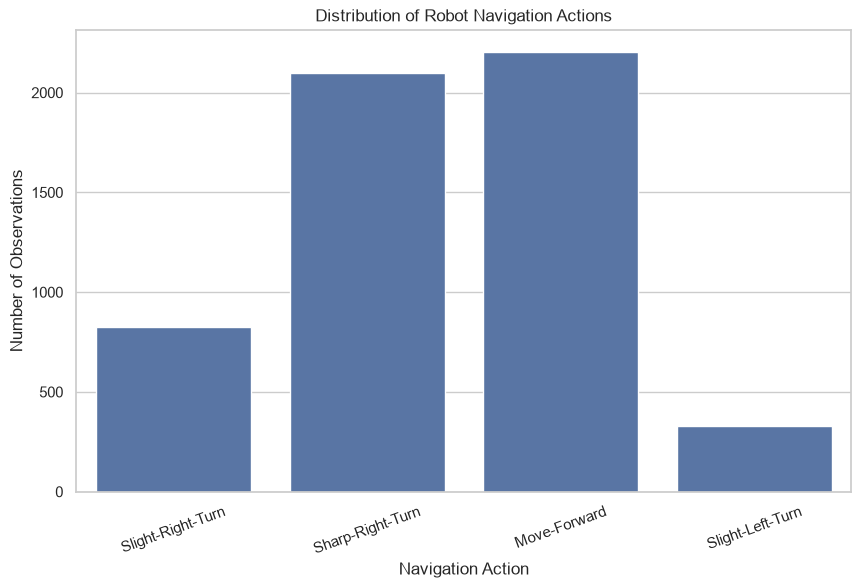

In [116]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Robot Navigation Actions")
plt.xlabel("Navigation Action")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)

plt.show()

### Class Distribution Observation

The target classes are not equally represented. `Move-Forward` and `Sharp-Right-Turn` contain many more observations than `Slight-Left-Turn`. This class imbalance should be considered later when the machine-learning models are evaluated, so accuracy alone should not be used to judge performance.

### Representative Sensor Distributions

Four sensors from different positions around the robot are inspected to understand the distribution of ultrasonic distance readings.

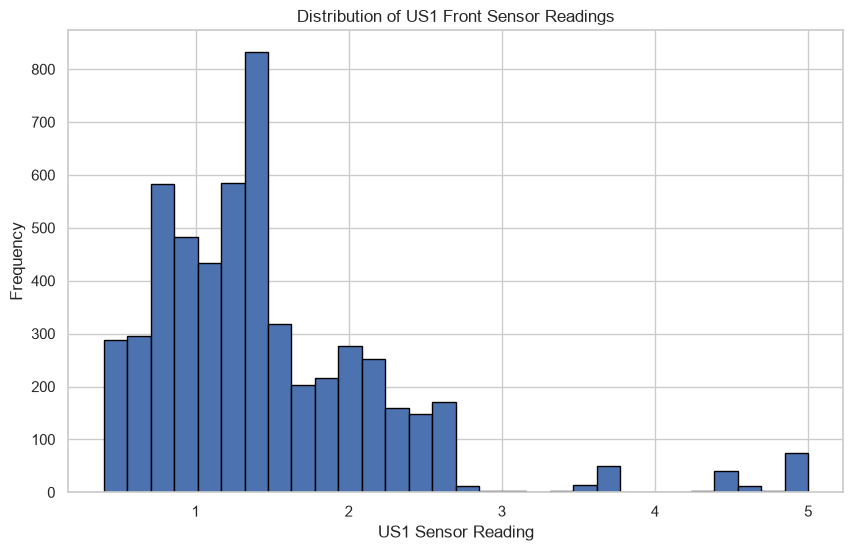

In [117]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US1"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US1 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US1 Front Sensor Readings")

plt.show()

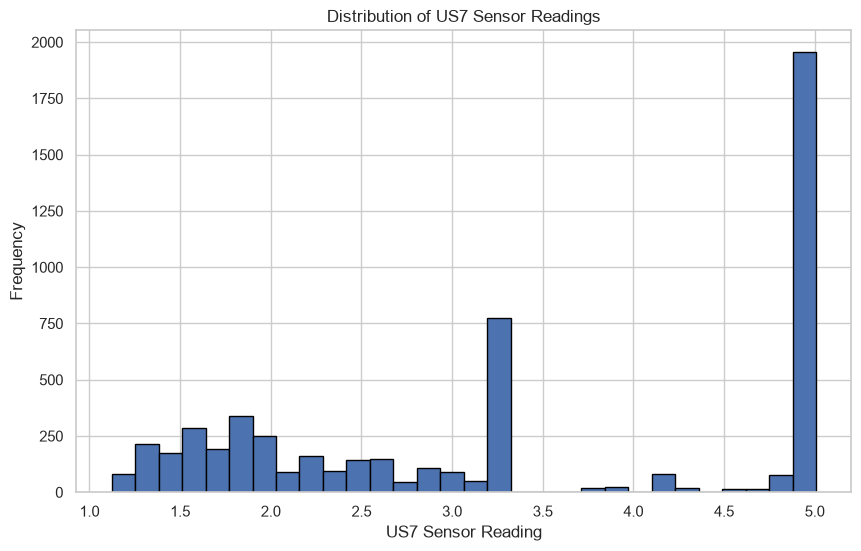

In [118]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US7"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US7 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US7 Sensor Readings")

plt.show()

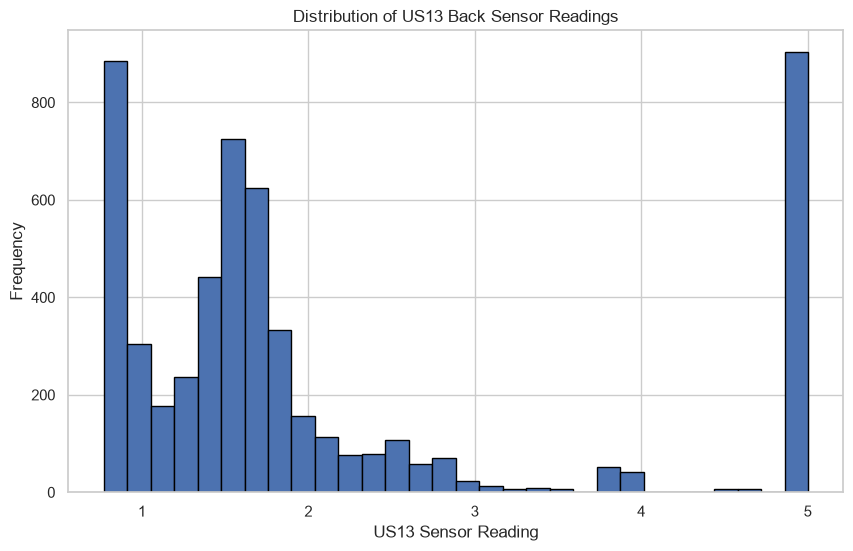

In [119]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US13"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US13 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US13 Back Sensor Readings")

plt.show()

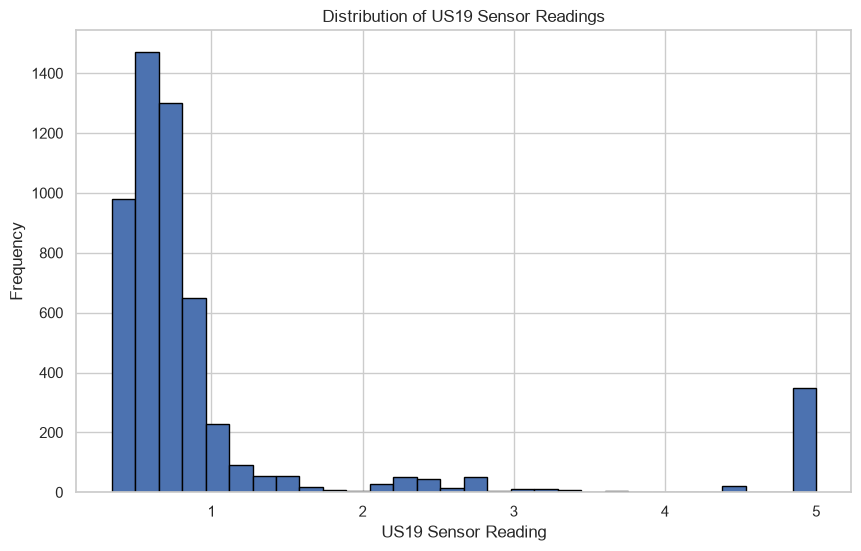

In [120]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["US19"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("US19 Sensor Reading")
plt.ylabel("Frequency")
plt.title("Distribution of US19 Sensor Readings")

plt.show()

### Sensor Distribution Observation

The sensor distributions are not identical across positions around the robot. Different sensors record different ranges and concentrations of distance values, which is expected because they measure obstacles from different directions.

### Front and Back Sensor Relationship

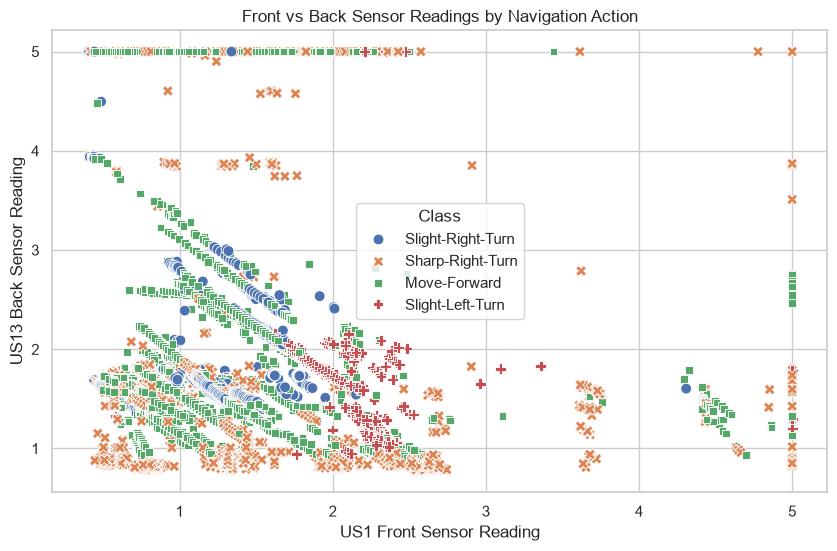

In [121]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="US1",
    y="US13",
    hue="Class",
    style="Class",
    s=60
)

plt.title("Front vs Back Sensor Readings by Navigation Action")
plt.xlabel("US1 Front Sensor Reading")
plt.ylabel("US13 Back Sensor Reading")

plt.show()

The scatterplot shows the relationship between the front sensor (`US1`) and the back sensor (`US13`) for the four navigation actions. The classes show some different patterns, but there is also overlap between several classes. This suggests that these two sensor readings alone may not be enough to clearly distinguish all four navigation actions.

### Side Sensor Relationship

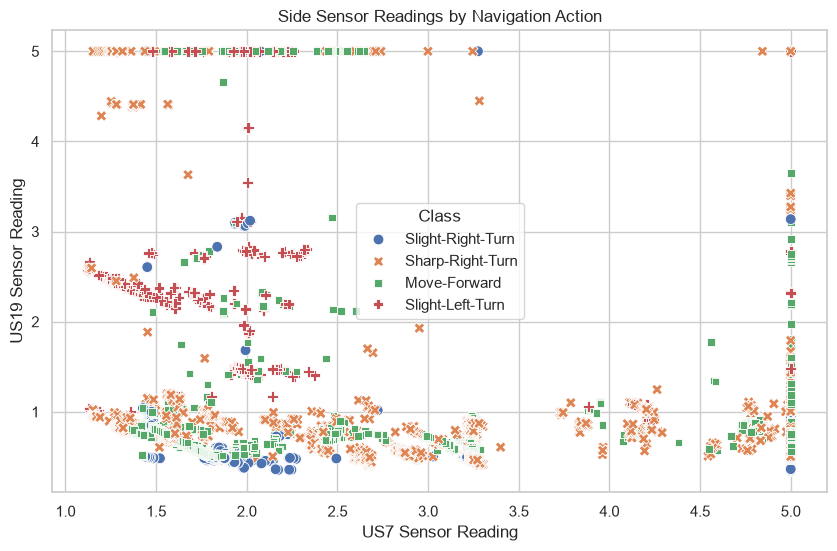

In [122]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="US7",
    y="US19",
    hue="Class",
    style="Class",
    s=60
)

plt.title("Side Sensor Readings by Navigation Action")
plt.xlabel("US7 Sensor Reading")
plt.ylabel("US19 Sensor Reading")

plt.show()

The side-sensor scatterplot shows that the navigation classes occupy different regions in some parts of the graph, but substantial overlap is also present. This suggests that the `US7` and `US19` readings alone are not sufficient to clearly distinguish all four navigation actions.

### Selected Multi-Sensor Relationships

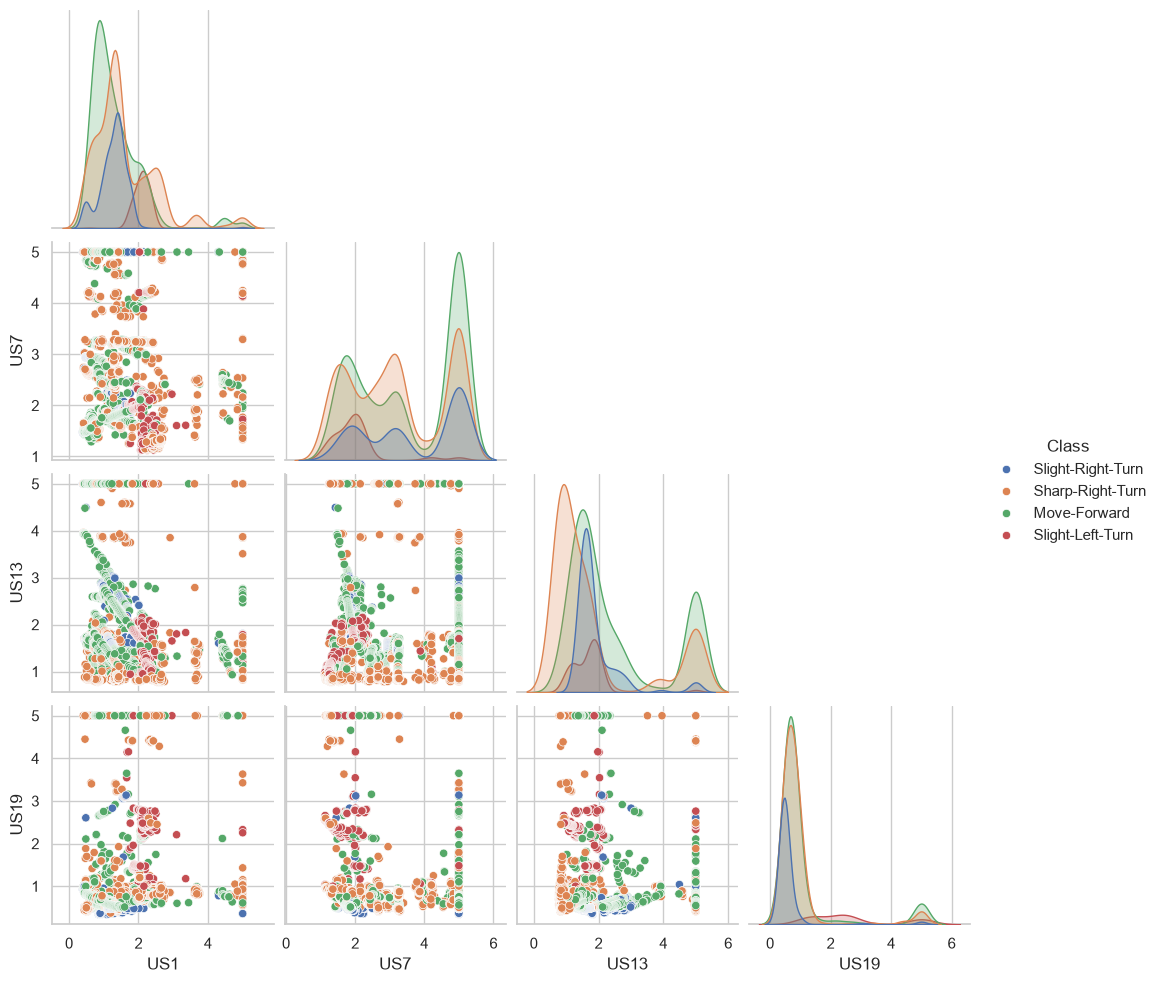

In [123]:
sns.pairplot(
    df,
    vars=[
        "US1",
        "US7",
        "US13",
        "US19"
    ],
    hue="Class",
    corner=True
)

plt.show()

The pairplot compares four representative sensors positioned around different parts of the robot. Some navigation classes show different concentration patterns across the selected sensor combinations, but considerable overlap remains. This indicates that using information from multiple sensors is likely to be more useful than relying on only one or two individual sensor readings.

## 9. Data Preparation and Exploratory Analysis Summary

The dataset contains 5,456 observations, 24 numerical ultrasonic sensor features, and one target variable with four navigation classes.

The data audit found no missing values or duplicate rows, and all sensor readings were non-negative. The original observations were therefore retained without unnecessary imputation or row removal.

The target distribution is imbalanced. `Move-Forward` and `Sharp-Right-Turn` are the most frequent classes, while `Slight-Left-Turn` is the least frequent. Therefore, later model evaluation should consider class-wise performance rather than relying only on overall accuracy.

Exploratory analysis shows that sensor measurements vary according to position around the robot and that different navigation actions exhibit different patterns, although substantial class overlap remains in the selected feature relationships.

The dataset is now ready for feature and target definition and for designing an appropriate training, validation, and test strategy.

## 10. Feature and Target Definition

The 24 ultrasonic sensor readings are used as input features, while `Class` is the target variable containing the robot's navigation action.

In [124]:
X = df[sensor_columns].copy()
y = df["Class"].copy()

In [125]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", X.shape[1])

Feature shape: (5456, 24)
Target shape: (5456,)
Number of features: 24


## 11. Training, Validation, and Test Split

The dataset contains sequential robot sensor measurements. Randomly shuffling the observations could place measurements recorded very close together into both training and evaluation sets.

Therefore, the original row order is preserved and `shuffle=False` is used.

The dataset is divided into:

- first 60%: training set
- next 20%: validation set
- final 20%: test set

The training set is used to fit models. The validation set is used for model and parameter selection. The final test set is kept untouched until the final model has been selected.

In [126]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

In [127]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    shuffle=False
)

In [128]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3273, 24) (3273,)
Validation set: (1091, 24) (1091,)
Test set: (1092, 24) (1092,)


In [129]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class counts:
Class
Move-Forward         1283
Sharp-Right-Turn     1243
Slight-Right-Turn     564
Slight-Left-Turn      183
Name: count, dtype: int64

Training class percentages:
Class
Move-Forward         39.20
Sharp-Right-Turn     37.98
Slight-Right-Turn    17.23
Slight-Left-Turn      5.59
Name: proportion, dtype: float64


In [130]:
print("Validation class counts:")
print(y_val.value_counts())

print("\nValidation class percentages:")
print((y_val.value_counts(normalize=True) * 100).round(2))

Validation class counts:
Class
Move-Forward         493
Sharp-Right-Turn     446
Slight-Right-Turn    114
Slight-Left-Turn      38
Name: count, dtype: int64

Validation class percentages:
Class
Move-Forward         45.19
Sharp-Right-Turn     40.88
Slight-Right-Turn    10.45
Slight-Left-Turn      3.48
Name: proportion, dtype: float64


### Leakage Prevention

The final test set is separated before model development and is not used for parameter selection or model comparison.

Because the observations are sequential, the original ordering is preserved rather than randomly shuffling nearby sensor measurements across the training, validation, and test sets.

Any preprocessing required by a model must be fitted using the training data only. The validation set may be used to compare model configurations, while the test set remains untouched until final evaluation.

## 12. Majority-Class Baseline

Before training a machine-learning model, a simple majority-class baseline is created. The baseline always predicts the most common class in the training set.

In [131]:
baseline_class = y_train.value_counts().idxmax()

print("Majority training class:", baseline_class)

Majority training class: Move-Forward


In [132]:
baseline_val_pred = np.full(
    len(y_val),
    baseline_class
)

print("Number of baseline predictions:", len(baseline_val_pred))
print("First 10 predictions:", baseline_val_pred[:10])

Number of baseline predictions: 1091
First 10 predictions: ['Move-Forward' 'Move-Forward' 'Move-Forward' 'Move-Forward'
 'Move-Forward' 'Move-Forward' 'Move-Forward' 'Move-Forward'
 'Move-Forward' 'Move-Forward']


In [133]:
baseline_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

print("Baseline validation accuracy:", baseline_accuracy)
print(
    "Baseline validation accuracy (%):",
    baseline_accuracy * 100
)

Baseline validation accuracy: 0.45187901008249315
Baseline validation accuracy (%): 45.18790100824931


In [134]:
baseline_macro_f1 = f1_score(
    y_val,
    baseline_val_pred,
    average="macro",
    zero_division=0
)

print("Baseline validation Macro F1:", baseline_macro_f1)

Baseline validation Macro F1: 0.15561868686868688


In [135]:
print(
    classification_report(
        y_val,
        baseline_val_pred,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

     Move-Forward       0.45      1.00      0.62       493
 Sharp-Right-Turn       0.00      0.00      0.00       446
 Slight-Left-Turn       0.00      0.00      0.00        38
Slight-Right-Turn       0.00      0.00      0.00       114

         accuracy                           0.45      1091
        macro avg       0.11      0.25      0.16      1091
     weighted avg       0.20      0.45      0.28      1091



### Baseline Interpretation

The majority-class baseline predicts `Move-Forward` for every validation observation.

This produces moderate overall accuracy because `Move-Forward` is the most common validation class, but the baseline cannot correctly identify the other navigation actions. Its low Macro F1 score demonstrates why overall accuracy alone is not sufficient for this imbalanced classification problem.

The machine-learning models should meaningfully outperform this baseline, particularly across the less frequent classes.

## 13. K-Nearest Neighbours Classification

K-Nearest Neighbours (KNN) predicts the class of an observation using the classes of nearby observations.

Because KNN uses distances between observations, differences in feature scales can affect which observations are considered nearest. Therefore, the ultrasonic sensor features are standardized before KNN is applied.

A `Pipeline` is used so that `StandardScaler` is fitted using the training data and then applied consistently during validation. This prevents validation information from being used to fit the scaler.

In [ ]:
initial_knn_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]
)

initial_knn_pipeline.fit(
    X_train,
    y_train
)